# 04 · Galaxy SED explorer

Reconstructs individual galaxy spectra from stored PCA coefficients and compares them against direct BC03 synthesis, with nebular and dust layers.

**Contents:**
1. Data loading and setup
2. Galaxy selection
3. Helper functions
4. Static overview: SFH + SED panels for all four galaxies
5. Per-galaxy magnitude tables
6. **Interactive explorer** — change galaxy type and number of PCA components

> **Requirement:** `pip install ipywidgets` for the interactive cell.

## Merger tree

Set `TREE` below. Every per-tree constant comes from `galspectra.trees`, so the
tree is chosen in exactly one place and the sample file cannot disagree with the
coefficient product.


In [1]:
# ── Merger tree ─────────────────────────────────────────────────────────────
# "MR"   Millennium-I   (default)
# "MRII" Millennium-II  — trees live on an external drive and there is no
#                         galaxy_table_MRII.npz, so this is often unavailable.
#
# Every per-tree constant comes from galspectra.trees, so the sample file and the
# coefficient product cannot disagree about which simulation this is. Selecting a
# tree whose data is absent fails immediately, naming the path: TREE.require()
# never falls back to the other tree, because that would mean every number below
# quietly described a different simulation from the one in the heading.
from galspectra.trees import get_tree

TREE = get_tree("MR")          # Millennium-I
print(f"Tree: {TREE.label}  ({TREE.pretty})")


Tree: MR  (Millennium-I)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
LGAL_ROOT    = PROJECT_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
FILTER_DIR   = LGAL_ROOT / 'SpecPhotTables/Filters'

# ── Physical constants ────────────────────────────────────────────────────
_D_10PC_CM        = 3.0857e19
_FOUR_PI_10PC_SQ  = 4.0 * np.pi * _D_10PC_CM**2
_YOUNG_THR_GYR    = 0.010   # 10 Myr birth-cloud boundary
# ── PCA results ───────────────────────────────────────────────────────────
pca = np.load(PROJECT_ROOT / 'data/pca_results_bc03.npz', allow_pickle=True)
pca_wave       = pca['wave']          # (351,) Å
pca_components = pca['components']    # (50, 351)
pca_mean_pca   = pca['mean']          # (351,) mean of normalized training SEDs
pca_params     = pca['params']        # (1200, 2)
pca_param_names = list(pca['param_names'])
pca_variance   = pca['variance']
pca_cumvar     = np.cumsum(pca_variance)
norm_meta = pca['norm'].item() if pca['norm'].ndim == 0 else dict(pca['norm'])

# ── Pre-computed CSP coefficients for all galaxies ───────────────────────
synth = np.load(TREE.require(TREE.coeffs_path(PROJECT_ROOT / 'data'),
                             'the PCA coefficient product'))
all_pca_coeffs = synth['pca_coeffs']    # (N_gal, 50)

# ── L-GALAXIES galaxy sample ──────────────────────────────────────────────
G = np.load(TREE.require(TREE.sample_path(LGAL_ROOT),
                         'the L-GALAXIES galaxy sample'),
            allow_pickle=True)
mag     = G['Mag']      # (N,5) intrinsic AB magnitudes, SDSS ugriz
magdust = G['MagDust']  # (N,5) dust-attenuated

# ── galspectra modules ────────────────────────────────────────────────────
from galspectra.lgalaxies import load_sfh_table, extract_sfh
from galspectra.utils.grid import build_param_grid
from galspectra.csp.interpolator import PCACoefficientInterpolator
from galspectra.csp.builder import build_csp_coefficients
from galspectra.csp.reconstruct import reconstruction_sed_from_pca
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import compute_ab_magnitudes
from galspectra.photometry.dust import apply_dust_to_seds

sfh_table  = load_sfh_table(LGAL_ROOT / 'AuxCode/Python/Database_SFH_table.fits')
ages_grid, Z_grid, coeff_grid = build_param_grid(pca_params, pca['coeffs'], pca_param_names)
interpolator = PCACoefficientInterpolator(ages_grid, Z_grid, coeff_grid)
filters = load_sdss_filters(FILTER_DIR)
# ── BC03 library for direct SED (same wavelength grid as pca_wave) ────────
from galspectra.sps.bc03_backend import BC03Library, get_bc03_spectrum, BC03_METALLICITIES
BC03_DIR   = LGAL_ROOT / 'SpecPhotTables/FullSEDs'
_bc03_lib  = BC03Library(BC03_DIR,
                          wave_min=float(pca_wave[0]),
                          wave_max=float(pca_wave[-1]))
print('Pre-loading BC03 files for direct SED...', end=' ', flush=True)
for _Z in BC03_METALLICITIES:
    _bc03_lib.get(_Z)
print('done.')
bands   = ['u', 'g', 'r', 'i', 'z']
band_idx = {b: i for i, b in enumerate(bands)}

print(f'PCA: {pca_components.shape[0]} components over {len(pca_wave)} wavelength bins '
      f'({pca_wave[0]:.0f}–{pca_wave[-1]:.0f} Å)')
print(f'Cumulative variance: PC1={pca_cumvar[0]*100:.1f}%  '
      f'PC10={pca_cumvar[9]*100:.2f}%  PC50={pca_cumvar[-1]*100:.4f}%')
print(f'Tree            : {TREE.label}  ({TREE.pretty})')
print(f'Galaxies loaded : {len(G):,}')

# ── Nebular emission ────────────────────────────────────────────────────
SHOW_NEBULAR  = False      # set False to hide nebular overlay
_QH0_FILE     = PROJECT_ROOT / 'data/qh0_grid_bc03.npz'
if SHOW_NEBULAR and _QH0_FILE.exists():
    from galspectra.nebular.ionizing import build_qh0_interpolator
    from galspectra.nebular.emission import csp_nebular_sed
    qh0_interp      = build_qh0_interpolator(_QH0_FILE)
    _HAL_PER_PHOTON = 1.37e-12   # erg/photon (Kennicutt 1998)
    print('Q(H0) interpolator loaded.')
else:
    qh0_interp = None
    if SHOW_NEBULAR:
        print('WARNING: data/qh0_grid_bc03.npz not found — nebular overlay disabled.')


(1200, 2)
[[ 1.00000000e-04 -2.30103000e+00]
 [ 1.00000000e-04 -1.69897000e+00]
 [ 1.00000000e-04 -6.98970004e-01]
 [ 1.00000000e-04 -3.97940009e-01]
 [ 1.00000000e-04  0.00000000e+00]
 [ 1.00000000e-04  3.97940009e-01]
 [ 1.06123769e-04 -2.30103000e+00]
 [ 1.06123769e-04 -1.69897000e+00]
 [ 1.06123769e-04 -6.98970004e-01]
 [ 1.06123769e-04 -3.97940009e-01]]
Pre-loading BC03 files for direct SED... done.
PCA: 50 components over 831 wavelength bins (805–29950 Å)
Cumulative variance: PC1=68.2%  PC10=99.99%  PC50=100.0000%
Tree            : MR  (Millennium-I)
Galaxies loaded : 11,328


In [3]:
valid      = mag[:, 2] < 90.0
valid_dust = magdust[:, 2] < 90.0
valid_both = valid & valid_dust
bt         = G['BulgeMass'] / (G['StellarMass'] + 1e-10)
sfr        = G['Sfr']
logmstar   = np.log10(G['StellarMass'] + 1e-10)   # StellarMass already in Msun
gr         = mag[:, 1] - mag[:, 2]
ssfr       = sfr / (G['StellarMass'] + 1e-10)

def _pick(mask, sort_by=None, pick='median'):
    idx = np.where(mask & valid_both)[0]
    if len(idx) == 0:
        raise ValueError('No candidates found — relax selection criteria')
    if sort_by is not None:
        idx = idx[np.argsort(sort_by[idx])]
    return idx[-1] if pick == 'max' else idx[len(idx) // 2]

i_ell = _pick(valid_both & (bt > 0.8)  & (sfr < 0.1) & (gr > 0.55) & (logmstar > 10.0),
              sort_by=gr, pick='max')           # reddest massive elliptical
i_sp  = _pick(valid_both & (bt < 0.2)  & (gr < 0.35) & (logmstar > 9.5) & (sfr > 0.5))
i_gv  = _pick(valid_both & (gr > 0.40) & (gr < 0.50) & (bt > 0.3) & (bt < 0.6) & (logmstar > 10.0))
i_sb  = _pick(valid_both & (bt < 0.3)  & (logmstar > 9.0) & (logmstar < 10.5),
              sort_by=ssfr, pick='max')         # highest sSFR disk galaxy

galaxy_labels  = ['Red elliptical', 'Blue spiral', 'Green valley', 'Starburst']
galaxy_indices = [i_ell, i_sp, i_gv, i_sb]

print(f'{"Type":<20} {"idx":>6} {"logM*":>6} {"g-r":>6} {"B/T":>5} {"SFR (Msun/yr)":>14}')
print('-' * 60)
for lbl, idx in zip(galaxy_labels, galaxy_indices):
    print(f'{lbl:<20} {idx:>6d} {logmstar[idx]:>6.2f} {gr[idx]:>6.3f} '
          f'{bt[idx]:>5.2f} {sfr[idx]:>14.3f}')


Type                    idx  logM*    g-r   B/T  SFR (Msun/yr)
------------------------------------------------------------
Red elliptical         2287  11.32  0.763  0.84          0.013
Blue spiral            6611   9.70  0.203  0.00          1.356
Green valley           3721  11.55  0.464  0.39         28.207
Starburst              8309   9.14  0.057  0.09          3.885


In [4]:
FILTER_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
                  'i': '#FF9800', 'z': '#795548'}

def _reconstruct_abs(coeffs_n, mass, components_n):
    """Reconstruct SED (first n components) and scale to absolute flux at 10 pc."""
    if mass <= 0:
        return np.zeros(len(pca_wave))
    sed_per_msun = reconstruction_sed_from_pca(
        coeffs_n / mass, components_n, pca_mean_pca, norm_meta)
    return sed_per_msun * mass / _FOUR_PI_10PC_SQ


def reconstruct_sed(galaxy_idx, n_components=50, rng=None):
    """
    Reconstruct intrinsic and dust-attenuated SEDs for one galaxy.

    Uses the first `n_components` PCA components.  The stored mass-weighted
    coefficient vector (disk + bulge, all ages) is truncated to n_components
    for the intrinsic SED.  For dust, the four sub-SEDs (young/old × disk/bulge)
    are rebuilt with the same truncation.

    Returns
    -------
    sed_i : (N_wave,) erg/s/Å/cm²  — intrinsic (no dust)
    sed_d : (N_wave,) erg/s/Å/cm²  — dust-attenuated
    sfh   : dict — SFH from extract_sfh
    """
    if rng is None:
        rng = np.random.default_rng(galaxy_idx)   # fixed seed → reproducible dust

    sfh  = extract_sfh(G[galaxy_idx], sfh_table)
    ages = sfh['age_Gyr']
    P_n  = pca_components[:n_components]           # (n, N_wave)

    # ── Intrinsic SED from stored coefficients ────────────────────────────
    total_mass  = sfh['disk_mass'].sum() + sfh['bulge_mass'].sum()
    coeffs_full = all_pca_coeffs[galaxy_idx]        # (50,)
    sed_i = _reconstruct_abs(coeffs_full[:n_components], total_mass, P_n)

    # ── Four-component SEDs for dust model ────────────────────────────────
    is_young = ages < _YOUNG_THR_GYR
    is_old   = ~is_young

    def _sub(mask, Z_key, mass_key):
        m = sfh[mass_key][mask].sum()
        if m <= 0:
            return np.zeros(len(pca_wave))
        c = build_csp_coefficients(
            interpolator, ages[mask], sfh[Z_key][mask], sfh[mass_key][mask])
        return _reconstruct_abs(c[:n_components], m, P_n)

    sed_do = _sub(is_old,   'logzsol_disk',  'disk_mass')
    sed_dy = _sub(is_young, 'logzsol_disk',  'disk_mass')
    sed_bo = _sub(is_old,   'logzsol_bulge', 'bulge_mass')
    sed_by = _sub(is_young, 'logzsol_bulge', 'bulge_mass')

    sed_d = apply_dust_to_seds(
        pca_wave, sed_do, sed_dy, sed_bo, sed_by,
        float(G[galaxy_idx]['ColdGas']),
        float(G[galaxy_idx]['ColdGasRadius']),
        G[galaxy_idx]['MetalsColdGas'],
        float(G[galaxy_idx]['CosInclination']),
        redshift=0.0, hubble_h=0.673, rng=rng,
    )
    return sed_i, sed_d, sfh


def _filter_overlay(ax, sed, scale_frac=0.15):
    """Add shaded SDSS filter transmission curves to an SED axis."""
#     scale = scale_frac * np.max(sed[sed > 0]) if np.any(sed > 0) else 1.0
    scale = 1.0
    for band, (wf, tf) in filters.items():
        tf_on_sed = np.interp(pca_wave, wf, tf, left=0.0, right=0.0)
        ax.fill_between(pca_wave, tf_on_sed * scale,
                        alpha=0.10, color=FILTER_COLORS[band])
        peak = np.argmax(tf_on_sed)
        ax.text(pca_wave[peak], tf_on_sed[peak] * scale * 1.08, band,
                ha='center', va='bottom', fontsize=8,
                color=FILTER_COLORS[band], fontweight='bold')

# ── PCA reconstruction residuals ─────────────────────────────────────────

def _frac_err(sed_pca, sed_true):
    """Fractional error in percent; NaN where the reference is non-positive."""
    with np.errstate(divide='ignore', invalid='ignore'):
        r = 100.0 * (sed_pca - sed_true) / sed_true
    return np.where(sed_true > 0, r, np.nan)


def _residual_panel(ax, pairs, show_ylabel=False):
    """Fractional-error subpanel.  pairs: list of (sed_pca, sed_true, color, label)."""
    ax.axhspan(-5, 5, color='gray', alpha=0.15, lw=0, zorder=0)
    ax.axhline(0, color='k', lw=0.8, zorder=1)
    for sed_pca, sed_true, color, label, lw, l_alpha in pairs:
        ax.plot(pca_wave, _frac_err(sed_pca, sed_true),
                color=color, lw=lw, label=label, zorder=3, alpha = l_alpha)
    ax.set_ylim(-10, 10)
    ax.set_xlim(pca_wave[0], pca_wave[-1])
    ax.set_yticks([-10, -5, 0, 5, 10])
    ax.set_xlabel('Wavelength (Å)')
    if show_ylabel:
        ax.set_ylabel('(PCA − true)/true  [%]', fontsize=9)
    else:
        ax.set_yticklabels([])

# ── Direct (non-PCA) CSP helpers ─────────────────────────────────────────

def _direct_csp_components(sfh):
    """Return dict{disk_old, disk_young, bulge_old, bulge_young} in erg/s/Å/cm² at 10 pc."""
    ages   = sfh['age_Gyr']
    N_wave = len(pca_wave)
    result = {k: np.zeros(N_wave)
              for k in ('disk_old', 'disk_young', 'bulge_old', 'bulge_young')}

    for j in range(len(ages)):
        age = ages[j]
        tag = 'young' if age < _YOUNG_THR_GYR else 'old'

        m_disk = sfh['disk_mass'][j]
        if m_disk > 0:
            Z = 0.02 * 10.0 ** sfh['logzsol_disk'][j]
            _, flux = get_bc03_spectrum(age, Z, BC03_DIR, _bc03_lib)
            result[f'disk_{tag}'] += m_disk * flux

        m_bulge = sfh['bulge_mass'][j]
        if m_bulge > 0:
            Z = 0.02 * 10.0 ** sfh['logzsol_bulge'][j]
            _, flux = get_bc03_spectrum(age, Z, BC03_DIR, _bc03_lib)
            result[f'bulge_{tag}'] += m_bulge * flux

    for k in result:
        result[k] /= _FOUR_PI_10PC_SQ
    return result


def reconstruct_sed_direct(galaxy_idx, rng=None):
    """Intrinsic and dust-attenuated SEDs via direct BC03 SSP summation (no PCA)."""
    if rng is None:
        rng = np.random.default_rng(galaxy_idx)
    sfh   = extract_sfh(G[galaxy_idx], sfh_table)
    comps = _direct_csp_components(sfh)
    sed_i = (comps['disk_old'] + comps['disk_young'] +
             comps['bulge_old'] + comps['bulge_young'])
    sed_d = apply_dust_to_seds(
        pca_wave,
        comps['disk_old'],   comps['disk_young'],
        comps['bulge_old'],  comps['bulge_young'],
        float(G[galaxy_idx]['ColdGas']),
        float(G[galaxy_idx]['ColdGasRadius']),
        G[galaxy_idx]['MetalsColdGas'],
        float(G[galaxy_idx]['CosInclination']),
        redshift=0.0, hubble_h=0.673, rng=rng,
    )
    return sed_i, sed_d




def compute_nebular_sed(galaxy_idx, f_ion=1.0, rng=None):
    """
    Nebular SED (emission lines + continuum) at 10 pc.

    Returns
    -------
    sed_neb_i : (N_wave,) erg/s/Å/cm² — intrinsic nebular SED
    sed_neb_d : (N_wave,) erg/s/Å/cm² — dust-attenuated nebular SED
    qh0_total : float — total Q(H0) [photons/s]
    ew_ha     : float — Hα rest-frame EW [Å] (vs stellar continuum)
    """
    if qh0_interp is None:
        z = np.zeros(len(pca_wave))
        return z, z, 0.0, 0.0
    if rng is None:
        rng = np.random.default_rng(galaxy_idx)
    sfh  = extract_sfh(G[galaxy_idx], sfh_table)
    ages = sfh['age_Gyr']

    sed_d_raw, qd = csp_nebular_sed(
        pca_wave, ages, sfh['logzsol_disk'],  sfh['disk_mass'],  qh0_interp, f_ion=f_ion)
    sed_b_raw, qb = csp_nebular_sed(
        pca_wave, ages, sfh['logzsol_bulge'], sfh['bulge_mass'], qh0_interp, f_ion=f_ion)
    sed_neb_disk  = sed_d_raw / _FOUR_PI_10PC_SQ
    sed_neb_bulge = sed_b_raw / _FOUR_PI_10PC_SQ
    qh0_total = qd + qb
    sed_neb_i = sed_neb_disk + sed_neb_bulge

    # Dust: nebular co-located with young stars (same treatment)
    sed_neb_d = apply_dust_to_seds(
        pca_wave,
        np.zeros(len(pca_wave)), sed_neb_disk,
        np.zeros(len(pca_wave)), sed_neb_bulge,
        float(G[galaxy_idx]['ColdGas']),
        float(G[galaxy_idx]['ColdGasRadius']),
        G[galaxy_idx]['MetalsColdGas'],
        float(G[galaxy_idx]['CosInclination']),
        redshift=0.0, hubble_h=0.673, rng=rng,
    )

    # EW(Hα) = integrated line flux / continuum flux density at 6563 Å
    total_mass = sfh['disk_mass'].sum() + sfh['bulge_mass'].sum()
    if total_mass > 0 and qh0_total > 0:
        coeffs_full = all_pca_coeffs[galaxy_idx]
        sed_cont = reconstruction_sed_from_pca(
            coeffs_full / total_mass, pca_components, pca_mean_pca, norm_meta)
        sed_cont *= total_mass / _FOUR_PI_10PC_SQ
        f_cont   = float(np.interp(6563.0, pca_wave, sed_cont))
        f_ha     = _HAL_PER_PHOTON * qh0_total / _FOUR_PI_10PC_SQ
        ew_ha    = f_ha / f_cont if f_cont > 0 else 0.0
    else:
        ew_ha = 0.0
    return sed_neb_i, sed_neb_d, qh0_total, ew_ha


print('Nebular helper defined.')



Nebular helper defined.


## 1. Static overview — SFH and SED for four galaxy types

All SEDs reconstructed with the full 50 PCA components.  Filter shading is scaled to 15% of the SED peak for visibility.

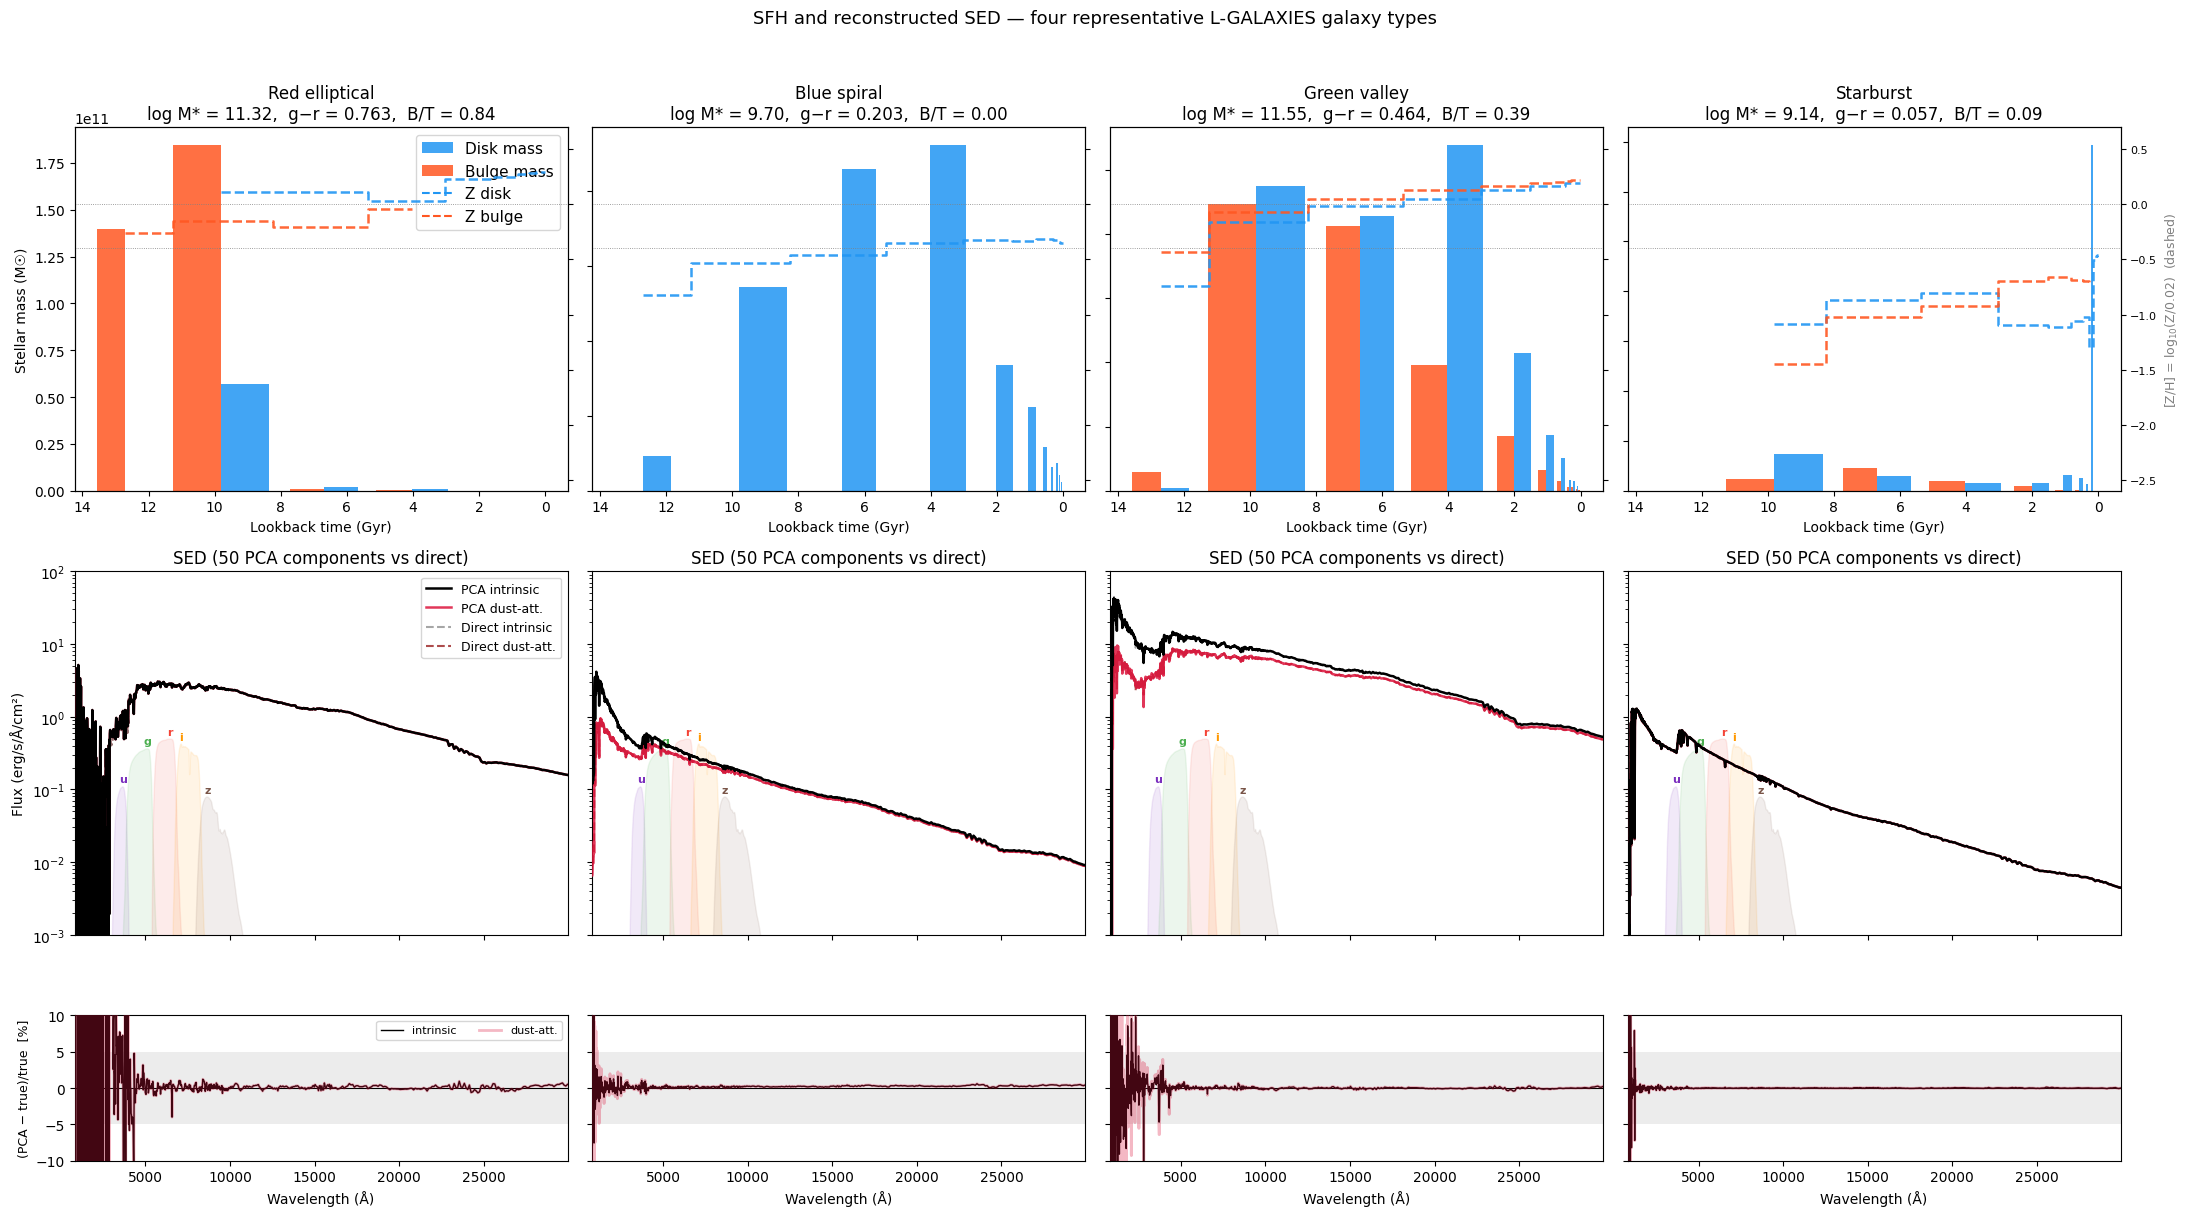

In [5]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 4, figsize=(22, 12),
                         gridspec_kw={'height_ratios': [3, 3, 1.2]})

for col, (lbl, gidx) in enumerate(zip(galaxy_labels, galaxy_indices)):

    # ── Row 0: SFH bar chart ──────────────────────────────────────────────
    ax = axes[0, col]
    sfh = extract_sfh(G[gidx], sfh_table)
    ages_bin = sfh['age_Gyr']
    dts      = sfh['dt_Gyr']
    w = dts * 0.40
    ax.bar(ages_bin - w/2, sfh['disk_mass'],  width=w, color='#2196F3',
           alpha=0.85, label='Disk mass')
    ax.bar(ages_bin + w/2, sfh['bulge_mass'], width=w, color='#FF5722',
           alpha=0.85, label='Bulge mass')
    ax.invert_xaxis()

    # ── Chemical evolution overlay on twin right y-axis ───────────────────
    ax2 = ax.twinx()
    mask_d = sfh['disk_mass']  > 0
    mask_b = sfh['bulge_mass'] > 0
    if mask_d.any():
        ax2.step(ages_bin[mask_d], sfh['logzsol_disk'][mask_d],
                 color='#2196F3', lw=1.8, ls='--', where='mid', alpha=0.9)
    if mask_b.any():
        ax2.step(ages_bin[mask_b], sfh['logzsol_bulge'][mask_b],
                 color='#FF5722', lw=1.8, ls='--', where='mid', alpha=0.9)
    ax2.axhline(0.0,  color='gray', lw=0.6, ls=':')   # [Z/H] = 0 (solar)
    ax2.axhline(-0.4, color='gray', lw=0.6, ls=':')   # [Z/H] = -0.4 (half-solar)
    ax2.set_ylim(-2.6, 0.7)
    ax2.tick_params(axis='y', labelsize=8)
    if col == len(galaxy_indices) - 1:
        ax2.set_ylabel('[Z/H] = log$_{10}$(Z/0.02)  (dashed)', fontsize=9, color='gray')
    else:
        ax2.set_yticklabels([])

    ax.set_xlabel('Lookback time (Gyr)')
    ax.set_title(lbl + '\n' + f'log M* = {logmstar[gidx]:.2f},  g−r = {gr[gidx]:.3f},  B/T = {bt[gidx]:.2f}')
    if col == 0:
        ax.set_ylabel('Stellar mass (M☉)')
        bar_handles, bar_labels = ax.get_legend_handles_labels()
        z_proxy = [Line2D([0], [0], color='#2196F3', lw=1.5, ls='--'),
                   Line2D([0], [0], color='#FF5722', lw=1.5, ls='--')]
        ax.legend(bar_handles + z_proxy,
                  bar_labels  + ['Z disk', 'Z bulge'],
                  fontsize=11)
    else:
        ax.set_yticklabels([])

    # ── Row 1: SED comparison (PCA solid, direct dotted) + filters ────────
    ax = axes[1, col]
    sed_i, sed_d, _ = reconstruct_sed(gidx)
    sed_i_d, sed_d_d = reconstruct_sed_direct(gidx)
    _neb_i, _neb_d, _qh0, _ew_ha = compute_nebular_sed(gidx)

    _filter_overlay(ax, sed_i)

    # PCA SEDs — solid lines
    ax.plot(pca_wave, sed_i,   color='black',   lw=1.8, label='PCA intrinsic', zorder=5)
    ax.plot(pca_wave, sed_d,   color='crimson', lw=1.8, label='PCA dust-att.', alpha=0.85, zorder=4)

    # Direct SEDs — dotted lines
    ax.plot(pca_wave, sed_i_d, color='gray',    lw=1.5, ls='--', alpha=0.7,
            label='Direct intrinsic', zorder=3)
    ax.plot(pca_wave, sed_d_d, color='darkred', lw=1.5, ls='--', alpha=0.7,
            label='Direct dust-att.', zorder=2)

    # Nebular emission — dot-dash lines
    if SHOW_NEBULAR and _qh0 > 0:
        ax.plot(pca_wave, _neb_i, color='limegreen', lw=1.5, ls='-.',
                label='Nebular (intr.)', zorder=6)
        ax.plot(pca_wave, _neb_d, color='darkgreen', lw=1.5, ls='-.',
                alpha=0.75, label='Nebular (dust)', zorder=5)
        if _ew_ha > 0.5:
            ax.text(0.97, 0.03, f'EW(Hα) = {_ew_ha:.0f} Å',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=8, color='limegreen')

    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1e2)
    ax.set_xlim(pca_wave[0], pca_wave[-1])
    ax.set_xticklabels([])
    ax.set_title('SED (50 PCA components vs direct'  + (' + nebular' if SHOW_NEBULAR else '') + ')')
    if col == 0:
        ax.set_ylabel('Flux (erg/s/Å/cm²)')
        ax.legend(fontsize=9)
    else:
        ax.set_yticklabels([])

    # ── Row 2: fractional error, PCA vs direct ───────────────────────────
    ax_r = axes[2, col]
    _residual_panel(ax_r, [
        (sed_i, sed_i_d, 'black',   'intrinsic', 1, 1),
        (sed_d, sed_d_d, 'crimson', 'dust-att.', 2, 0.3),
    ], show_ylabel=(col == 0))
    if col == 0:
        ax_r.legend(fontsize=8, ncol=2, loc='upper right')

plt.suptitle('SFH and reconstructed SED — four representative L-GALAXIES galaxy types',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/visualise_galaxy_seds.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Magnitude tables (50 components)

Comparison of synthetic photometry against L-GALAXIES stored `Mag` and `MagDust`.
Δ = synthetic − stored.

In [6]:
def _fmt(val, ref, sentinel=90.0):
    """Format synthetic mag, stored ref, and delta; handles sentinel values."""
    if ref > sentinel:
        return f'{val:>12.3f}', f'{"(no dust)":>14}', f'{"--":>8}'
    return f'{val:>12.3f}', f'{ref:>14.3f}', f'{val - ref:>+8.3f}'

for lbl, gidx in zip(galaxy_labels, galaxy_indices):
    sed_i, sed_d, _ = reconstruct_sed(gidx)
    mags_i = compute_ab_magnitudes(pca_wave, sed_i, filters)
    mags_d = compute_ab_magnitudes(pca_wave, sed_d, filters)

    print(f'  {lbl}  (galaxy #{gidx},  log M* = {logmstar[gidx]:.2f})')
    print(f'  {"Band":<5} {"Synth(intr)":>12} {"L-GAL Mag":>10} {"Δ":>8}'
          f' | {"Synth(dust)":>12} {"L-GAL MagDust":>14} {"Δ":>8}')
    print('  ' + '-' * 76)
    for b in bands:
        bi = band_idx[b]
        si, ri, di = _fmt(mags_i[b], mag[gidx, bi])
        sd, rd, dd = _fmt(mags_d[b], magdust[gidx, bi])
        print(f'  {b:<5} {si} {ri:>10} {di} | {sd} {rd} {dd}')
    print()


  Red elliptical  (galaxy #2287,  log M* = 11.32)
  Band   Synth(intr)  L-GAL Mag        Δ |  Synth(dust)  L-GAL MagDust        Δ
  ----------------------------------------------------------------------------
  u          -20.011        -20.020   +0.009 |      -20.010        -20.020   +0.010
  g          -21.691        -21.724   +0.033 |      -21.690        -21.724   +0.034
  r          -22.479        -22.488   +0.009 |      -22.479        -22.488   +0.009
  i          -22.830        -22.838   +0.008 |      -22.830        -22.838   +0.008
  z          -23.160        -23.160   +0.001 |      -23.159        -23.160   +0.001

  Blue spiral  (galaxy #6611,  log M* = 9.70)
  Band   Synth(intr)  L-GAL Mag        Δ |  Synth(dust)  L-GAL MagDust        Δ
  ----------------------------------------------------------------------------
  u          -19.212        -19.223   +0.010 |      -18.836        -19.223   +0.387
  g          -19.930        -19.938   +0.007 |      -19.674        -19.938   +0.2

## 3. Interactive SED explorer

Use the dropdown to select a galaxy type and the slider to control how many PCA
components are used for reconstruction.  The left panel shows the SED with SDSS
filter overlays; the right panel shows the magnitude residuals Δ = synthetic − stored.

**Expected behaviour:**
- At **n = 1** the SED is a smooth, featureless continuum (PC1 captures 88.7% of variance)
- Spectral features (4000 Å break, Hα, G-band) emerge by **n ≈ 5–10**
- Magnitude residuals |Δ| < 0.05 mag by **n = 50**


In [8]:
from ipywidgets import interact, Dropdown, IntSlider

galaxy_options = {lbl: idx for lbl, idx in zip(galaxy_labels, galaxy_indices)}

def _fmt(val, ref, sentinel=90.0):
    if ref > sentinel:
        return f'{val:>12.3f}', f'{"(no dust)":>14}', f'{"--":>8}'
    return f'{val:>12.3f}', f'{ref:>14.3f}', f'{val - ref:>+8.3f}'

@interact(
    galaxy_type=Dropdown(options=galaxy_options, description='Galaxy:',
                         style={'description_width': 'initial'}),
    n_components=IntSlider(min=1, max=50, step=1, value=50, description='N components:',
                           style={'description_width': 'initial'},
                           layout={'width': '400px'}),
)
def interactive_sed(galaxy_type=i_ell, n_components=50):
    gidx = galaxy_type
    lbl  = next(k for k, v in galaxy_options.items() if v == gidx)

    sed_i, sed_d, _ = reconstruct_sed(gidx, n_components)
    mags_i = compute_ab_magnitudes(pca_wave, sed_i, filters)
    mags_d = compute_ab_magnitudes(pca_wave, sed_d, filters)

    # Direct (non-PCA) SED for reference
    sed_i_d, sed_d_d = reconstruct_sed_direct(gidx)
    _neb_i, _neb_d, _qh0, _ew_ha = compute_nebular_sed(gidx)

    fig = plt.figure(figsize=(15, 6.5))
    gs  = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.22)
    ax_sed   = fig.add_subplot(gs[0, 0])
    ax_res   = fig.add_subplot(gs[1, 0], sharex=ax_sed)
    ax_delta = fig.add_subplot(gs[:, 1])

    # ── Left: SED + filters ───────────────────────────────────────────────
    _filter_overlay(ax_sed, sed_i)
    ax_sed.plot(pca_wave, sed_i, color='black',   lw=2.0, label='PCA intrinsic', zorder=5)
    ax_sed.plot(pca_wave, sed_d, color='crimson', lw=2.0, label='PCA dust-att.',
                alpha=0.5, zorder=4)

    # Direct SEDs — dotted reference lines
    ax_sed.plot(pca_wave, sed_i_d, color='gray',    lw=1.5, ls='--', alpha=0.7,
                label='Direct intrinsic', zorder=3)
    ax_sed.plot(pca_wave, sed_d_d, color='darkred', lw=1.5, ls='--', alpha=0.7,
                label='Direct dust-att.', zorder=2)

    # Nebular emission — dot-dash lines
    if SHOW_NEBULAR and _qh0 > 0:
        ax_sed.plot(pca_wave, _neb_i, color='limegreen', lw=1.5, ls='-.',
                    label='Nebular (intr.)', zorder=7)
        ax_sed.plot(pca_wave, _neb_d, color='darkgreen', lw=1.5, ls='-.',
                    alpha=0.75, label='Nebular (dust)', zorder=6)
        if _ew_ha > 0.5:
            ax_sed.text(0.97, 0.03, f'EW(H\u03b1) = {_ew_ha:.0f} \u00c5',
                        transform=ax_sed.transAxes, ha='right', va='bottom',
                        fontsize=9, color='limegreen')
    ax_sed.set_yscale('log')
    ax_sed.set_ylim(1e-3, 1e2)
    ax_sed.set_xlim(pca_wave[0], pca_wave[-1])
    ax_sed.tick_params(labelbottom=False)
    ax_sed.set_ylabel('Flux (erg/s/Å/cm²)', fontsize=11)
    cumvar_pct = pca_cumvar[n_components - 1] * 100
    _title_line1 = (f'{lbl}  (#{gidx}) — {n_components} PCA component'
                    + ('s' if n_components > 1 else '')
                    + f'  [{cumvar_pct:.2f}% variance]')
    _neb_suffix = '  |  Dash-dot = Nebular' if (SHOW_NEBULAR and _qh0 > 0) else ''
    ax_sed.set_title(_title_line1 + '\nSolid = PCA  |  Dotted = Direct SPS' + _neb_suffix,
                     fontsize=10)
    ax_sed.legend(fontsize=9)

    # ── Below: fractional error, PCA vs direct ───────────────────────────
    _residual_panel(ax_res, [
        (sed_i, sed_i_d, 'black',   'intrinsic', 1, 1),
        (sed_d, sed_d_d, 'crimson', 'dust-att.', 2, 0.5),
    ], show_ylabel=True)
    ax_res.legend(fontsize=8, ncol=2, loc='upper left')

    # ── Right: Δ magnitude bar chart ─────────────────────────────────────
    x = np.arange(len(bands))
    w = 0.35
    delta_i, delta_d = [], []
    for b in bands:
        bi = band_idx[b]
        delta_i.append(mags_i[b] - mag[gidx, bi])
        ref_d = magdust[gidx, bi]
        delta_d.append(mags_d[b] - ref_d if ref_d < 90.0 else 0.0)
    ax_delta.bar(x - w/2, delta_i, w, color='steelblue', alpha=0.85,
                 label='Δ intrinsic  (synth − L-GAL Mag)')
    ax_delta.bar(x + w/2, delta_d, w, color='tomato',    alpha=0.85,
                 label='Δ dust-att.  (synth − L-GAL MagDust)')
    ax_delta.axhline(0, color='k', lw=0.8)
    ax_delta.set_xticks(x)
    ax_delta.set_xticklabels(bands, fontsize=11)
    ax_delta.set_xlabel('SDSS band', fontsize=11)
    ax_delta.set_ylabel('Δ magnitude (mag)', fontsize=11)
    ax_delta.set_title('Magnitude residuals vs L-GALAXIES', fontsize=11)
    ax_delta.legend(fontsize=8)
    ax_delta.set_ylim(-2.0, 2.0)
    ax_delta.grid(axis='y', alpha=0.3)

    plt.show()

    # ── Magnitude table ───────────────────────────────────────────────────
    print(f'  {"Band":<5} {"Synth(intr)":>12} {"L-GAL Mag":>10} {"Δ":>8}'
          f' | {"Synth(dust)":>12} {"L-GAL MagDust":>14} {"Δ":>8}')
    print('  ' + '-' * 76)
    for b in bands:
        bi = band_idx[b]
        si, ri, di = _fmt(mags_i[b], mag[gidx, bi])
        sd, rd, dd = _fmt(mags_d[b], magdust[gidx, bi])
        print(f'  {b:<5} {si} {ri:>10} {di} | {sd} {rd} {dd}')


interactive(children=(Dropdown(description='Galaxy:', options={'Red elliptical': np.int64(2287), 'Blue spiral'…